In [1]:
import numpy as  np
import pandas as pd

# display the data set to do changes on it :
df=pd.read_csv('C:\\Users\\husse\\Desktop\\Junior\\Crop_recommendation (4).csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [2]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [4]:
X = df.loc[:, df.columns != 'label']
Y = df['label']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, 
    test_size=0.2, 
    shuffle=True, 
    stratify=Y,  # Preserve class distribution
    random_state=42
)

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Tuned parameters to prevent overfitting
model = RandomForestClassifier(
    n_estimators=100, # Reduce from default (100 is usually enough)
    max_depth=5,       # Limit tree depth (critical!)
    min_samples_split=10,  # Require more samples to split
    min_samples_leaf=5,    # Require more samples per leaf
    max_features='sqrt',   # Subsample features per tree
    random_state=42
)
model.fit(X_train, y_train)

# Evaluation
pred1 = model.predict(X_test)
pred1

array(['orange', 'banana', 'cotton', 'maize', 'orange', 'chickpea',
       'rice', 'blackgram', 'banana', 'orange', 'watermelon',
       'pomegranate', 'watermelon', 'maize', 'mothbeans', 'grapes',
       'grapes', 'mango', 'mango', 'apple', 'blackgram', 'apple',
       'mothbeans', 'kidneybeans', 'apple', 'jute', 'mothbeans',
       'watermelon', 'rice', 'coffee', 'mango', 'jute', 'banana',
       'coffee', 'jute', 'blackgram', 'grapes', 'grapes', 'blackgram',
       'jute', 'coconut', 'papaya', 'mango', 'maize', 'lentil', 'jute',
       'cotton', 'lentil', 'chickpea', 'mungbean', 'papaya',
       'pomegranate', 'pigeonpeas', 'watermelon', 'mango', 'blackgram',
       'papaya', 'papaya', 'coffee', 'lentil', 'lentil', 'mothbeans',
       'coffee', 'banana', 'papaya', 'rice', 'orange', 'coconut',
       'blackgram', 'pomegranate', 'banana', 'muskmelon', 'watermelon',
       'lentil', 'banana', 'coconut', 'mothbeans', 'mungbean', 'mungbean',
       'mango', 'coffee', 'watermelon', 'muskm

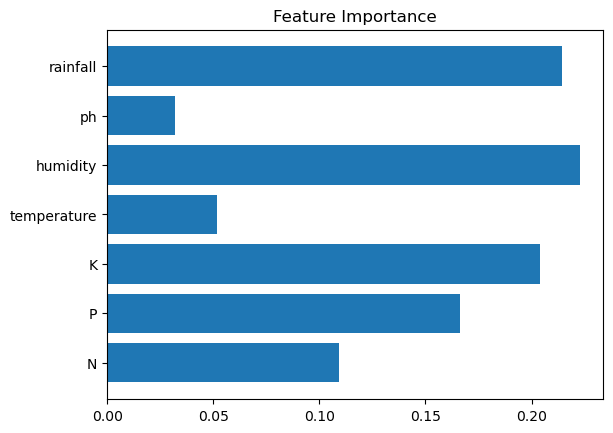

In [7]:
import matplotlib.pyplot as plt

plt.barh(X.columns, model.feature_importances_)
plt.title("Feature Importance")
plt.show()

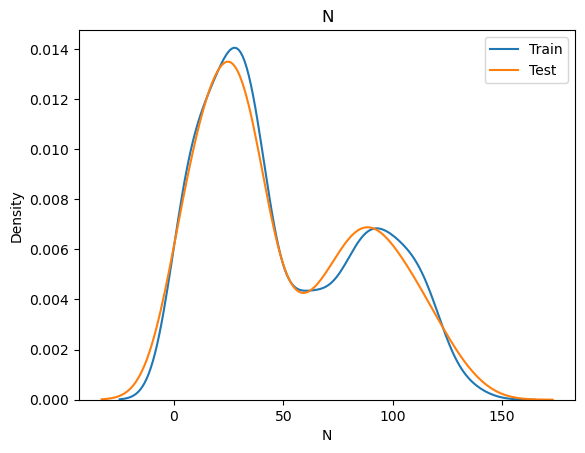

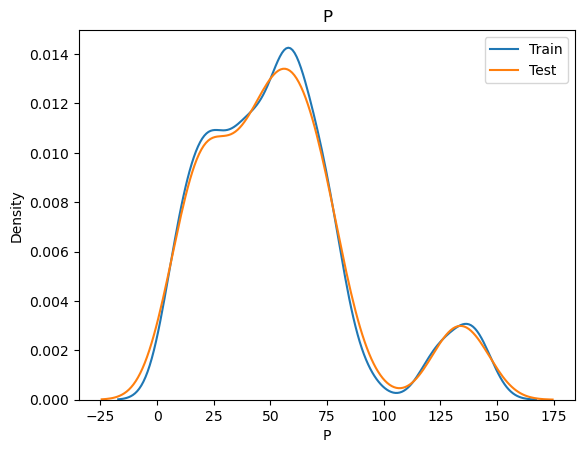

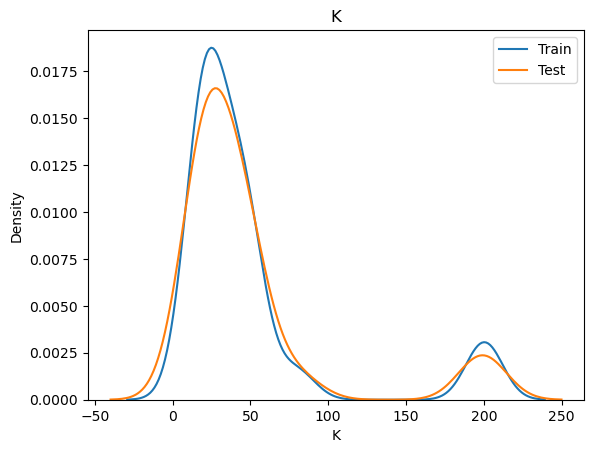

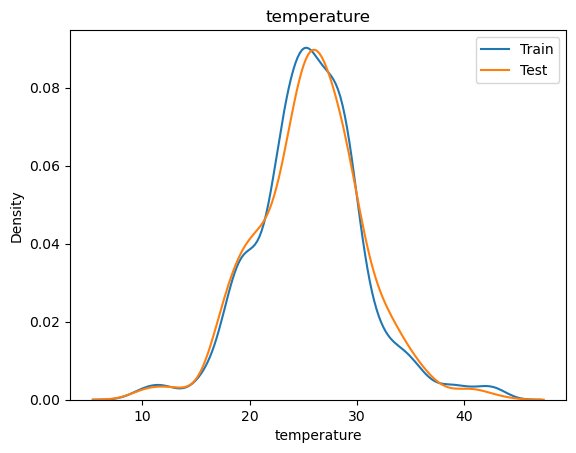

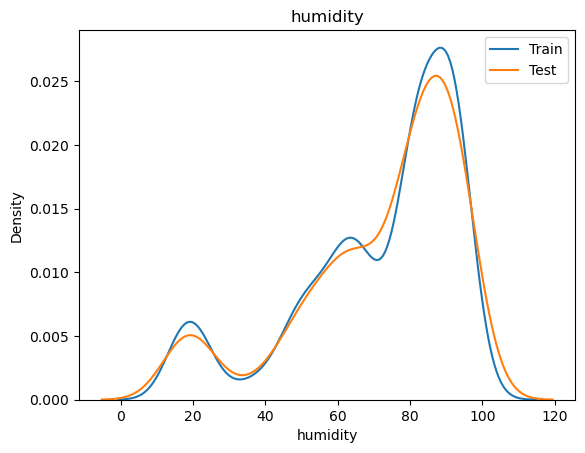

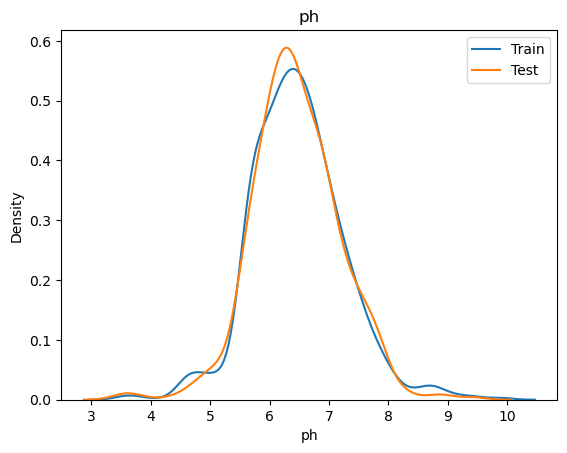

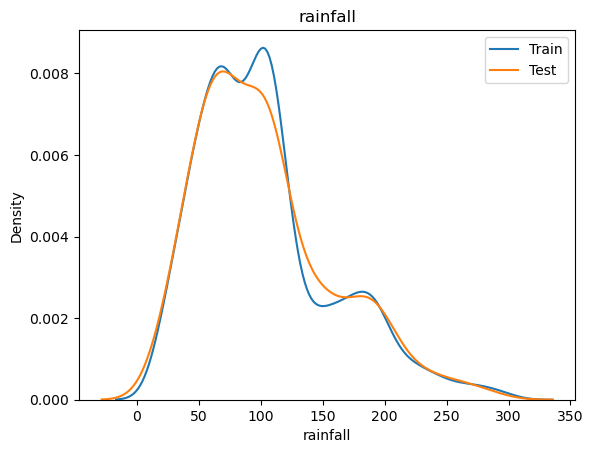

In [8]:
# Compare feature distributions between train/test
import seaborn as sns
for col in X.columns:
    plt.figure()
    sns.kdeplot(X_train[col], label='Train')
    sns.kdeplot(X_test[col], label='Test')
    plt.legend()
    plt.title(col)

In [9]:
print("Train class counts:\n", pd.Series(y_train).value_counts())
print("\nTest class counts:\n", pd.Series(y_test).value_counts())

Train class counts:
 label
orange         80
grapes         80
coconut        80
papaya         80
pomegranate    80
mango          80
jute           80
watermelon     80
rice           80
maize          80
pigeonpeas     80
blackgram      80
apple          80
muskmelon      80
coffee         80
mungbean       80
lentil         80
banana         80
cotton         80
mothbeans      80
kidneybeans    80
chickpea       80
Name: count, dtype: int64

Test class counts:
 label
orange         20
banana         20
pigeonpeas     20
mungbean       20
lentil         20
papaya         20
coconut        20
coffee         20
jute           20
kidneybeans    20
apple          20
mango          20
grapes         20
mothbeans      20
pomegranate    20
watermelon     20
blackgram      20
rice           20
chickpea       20
maize          20
cotton         20
muskmelon      20
Name: count, dtype: int64


In [10]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.9926136363636363
Test Accuracy: 0.990909090909091


In [11]:
from sklearn.svm import SVC
model3 = SVC()
model3.fit(X_train , y_train)
print(model3.score(X_train ,y_train))
print(model3.score(X_test ,y_test))

0.9767045454545454
0.9840909090909091


In [12]:
from sklearn.linear_model import LogisticRegression 
clf = LogisticRegression(max_iter = 100000).fit(X_train,y_train)
print('accuracy score (training)', clf.score(X_train,y_train))
print('accuracy score (test)', clf.score(X_test,y_test))

accuracy score (training) 0.9920454545454546
accuracy score (test) 0.9863636363636363
